In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
import warnings
warnings.filterwarnings('ignore')

Grid size: 11 x 11 x 11
Total nodes: 1331
Total DOFs: 3993
Lame parameters: λ=4.29e+06 Pa, μ=1.07e+06 Pa

Building system matrix...
Converting to CSR format...
Solving linear system...
Solution obtained!

Displacement ranges:
ux: [-0.021060, 0.005344] m
uy: [-0.021060, 0.005344] m
uz: [-0.000365, 0.100000] m

Strain ranges:
εxx: [-7.362741e-02, 6.840077e-02]
εyy: [-7.362741e-02, 6.840077e-02]
εzz: [-9.795494e-02, 5.000000e-01]

Stress ranges:
σxx: [-4.021757e+05, 2.142857e+06] Pa
σyy: [-4.021757e+05, 2.142857e+06] Pa
σzz: [-4.141587e+05, 3.214286e+06] Pa


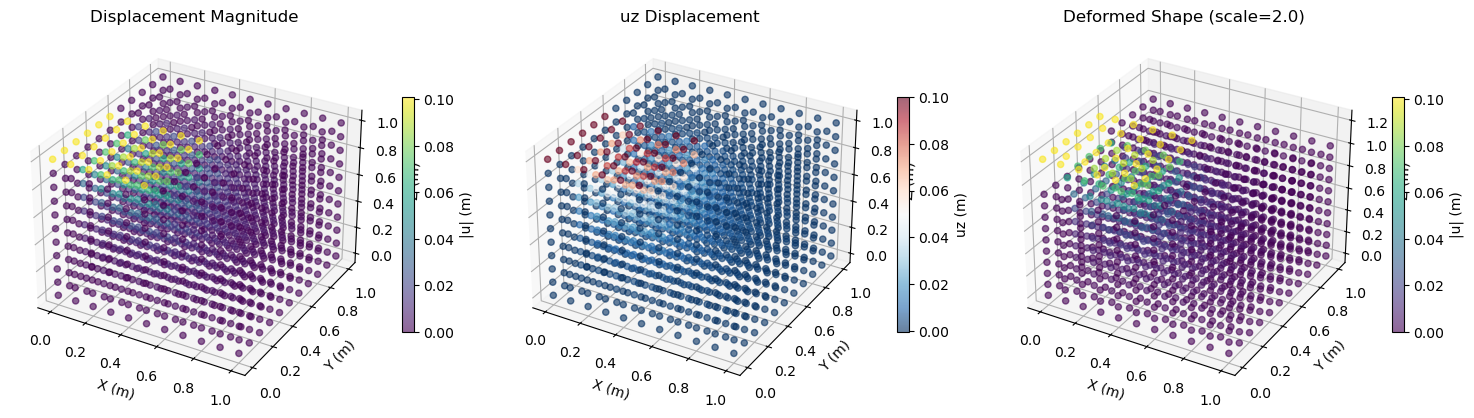

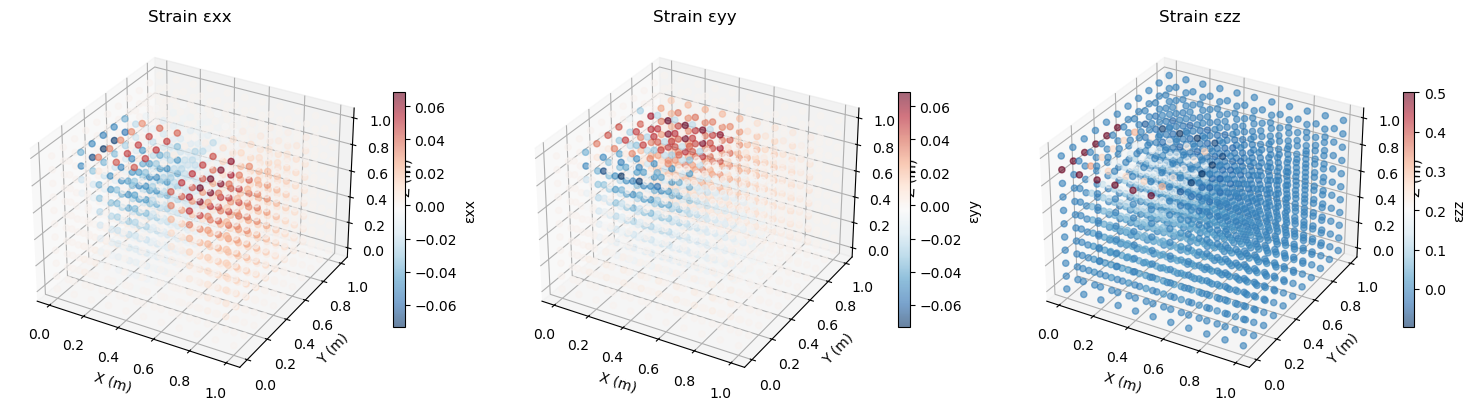

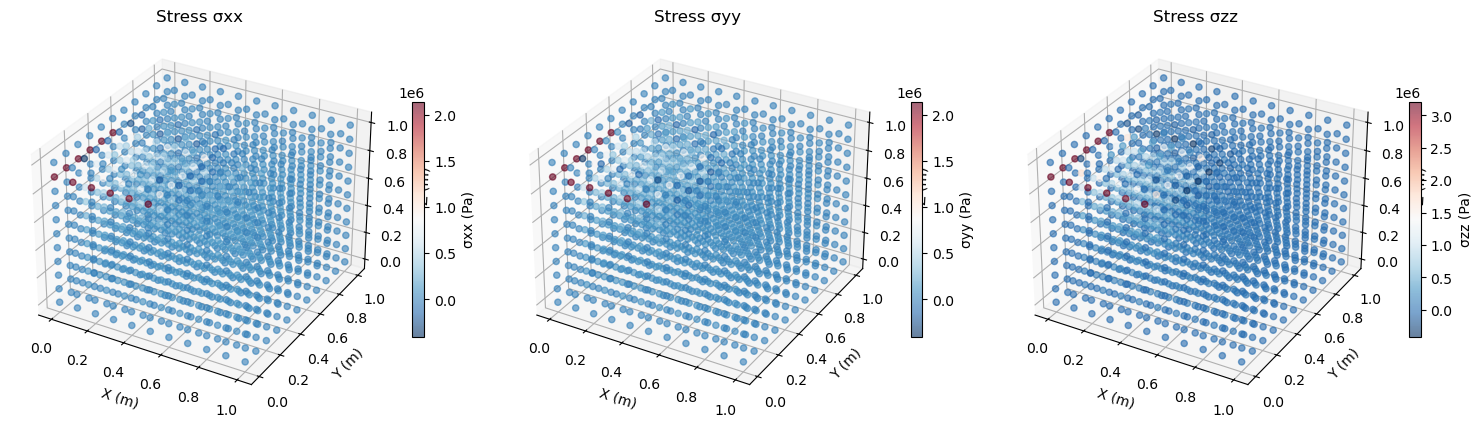


=== Solution Complete ===
Generated 3 visualization figures showing:
1. Displacement fields (magnitude, uz, deformed shape)
2. Strain fields (εxx, εyy, εzz)
3. Stress fields (σxx, σyy, σzz)


In [ ]:
# Problem parameters
E = 3e6  # Elastic modulus in Pa (3 MPa)
nu = 0.4  # Poisson's ratio
L = 1.0  # Domain size in meters

# Lame parameters
lam = E * nu / ((1 + nu) * (1 - 2 * nu))
mu = E / (2 * (1 + nu))

# Mesh parameters
nx, ny, nz = 101, 101, 101  # Grid points in each direction
dx = L / (nx - 1)
dy = L / (ny - 1)
dz = L / (nz - 1)

# Total number of nodes and degrees of freedom
n_nodes = nx * ny * nz
n_dof = 3 * n_nodes

print(f"Grid size: {nx} x {ny} x {nz}")
print(f"Total nodes: {n_nodes}")
print(f"Total DOFs: {n_dof}")
print(f"Lame parameters: λ={lam:.2e} Pa, μ={mu:.2e} Pa")

# Index function: convert (i,j,k,direction) to global DOF
def get_dof(i, j, k, direction):
    """
    direction: 0=ux, 1=uy, 2=uz
    """
    node_idx = i + j * nx + k * nx * ny
    return 3 * node_idx + direction

# Initialize system
A = lil_matrix((n_dof, n_dof))
b = np.zeros(n_dof)

# Build finite difference equations
# For each interior node, apply the elasticity equations
# Navier-Cauchy equation: μ∇²u + (λ+μ)∇(∇·u) = 0

print("\nBuilding system matrix...")

for k in range(nz):
    for j in range(ny):
        for i in range(nx):
            # Check boundary conditions
            # Bottom face: z=0, fully fixed
            if k == 0:
                for d in range(3):
                    dof = get_dof(i, j, k, d)
                    A[dof, dof] = 1.0
                    b[dof] = 0.0
                continue
            
            # Top face with prescribed displacement
            if k == nz - 1 and i <= nx//2 and j <= ny//2:
                # uz = 0.1 m
                dof = get_dof(i, j, k, 2)
                A[dof, dof] = 1.0
                b[dof] = 0.1
                
                # ux and uy are free, so we need equations for them
                for d in range(2):  # ux and uy
                    dof_d = get_dof(i, j, k, d)
                    
                    # Check if interior point for this direction
                    if i > 0 and i < nx-1 and j > 0 and j < ny-1:
                        # Apply PDE
                        # d²u/dx² + d²u/dy² + d²u/dz²
                        coef_center = -2/dx**2 - 2/dy**2 - 2/dz**2
                        
                        A[dof_d, dof_d] = mu * coef_center
                        
                        if i > 0:
                            A[dof_d, get_dof(i-1, j, k, d)] = mu / dx**2
                        if i < nx-1:
                            A[dof_d, get_dof(i+1, j, k, d)] = mu / dx**2
                        if j > 0:
                            A[dof_d, get_dof(i, j-1, k, d)] = mu / dy**2
                        if j < ny-1:
                            A[dof_d, get_dof(i, j+1, k, d)] = mu / dy**2
                        if k > 0:
                            A[dof_d, get_dof(i, j, k-1, d)] = mu / dz**2
                        
                        # Add (λ+μ)∇(∇·u) terms
                        # d/dx_d(du/dx + dv/dy + dw/dz)
                        # Contribution from d²u/dx²
                        if d == 0 and i > 0 and i < nx-1:
                            A[dof_d, get_dof(i+1, j, k, 0)] += (lam + mu) / dx**2
                            A[dof_d, get_dof(i-1, j, k, 0)] += (lam + mu) / dx**2
                            A[dof_d, dof_d] += -(lam + mu) * 2 / dx**2
                            
                            # d²v/dxdy
                            if j > 0 and j < ny-1:
                                A[dof_d, get_dof(i+1, j+1, k, 1)] += (lam + mu) / (4*dx*dy)
                                A[dof_d, get_dof(i+1, j-1, k, 1)] += -(lam + mu) / (4*dx*dy)
                                A[dof_d, get_dof(i-1, j+1, k, 1)] += -(lam + mu) / (4*dx*dy)
                                A[dof_d, get_dof(i-1, j-1, k, 1)] += (lam + mu) / (4*dx*dy)
                            
                            # d²w/dxdz
                            if k > 0:
                                A[dof_d, get_dof(i+1, j, k-1, 2)] += -(lam + mu) / (4*dx*dz)
                                A[dof_d, get_dof(i-1, j, k-1, 2)] += (lam + mu) / (4*dx*dz)
                                
                        elif d == 1 and j > 0 and j < ny-1:
                            A[dof_d, get_dof(i, j+1, k, 1)] += (lam + mu) / dy**2
                            A[dof_d, get_dof(i, j-1, k, 1)] += (lam + mu) / dy**2
                            A[dof_d, dof_d] += -(lam + mu) * 2 / dy**2
                            
                            # d²u/dxdy
                            if i > 0 and i < nx-1:
                                A[dof_d, get_dof(i+1, j+1, k, 0)] += (lam + mu) / (4*dx*dy)
                                A[dof_d, get_dof(i+1, j-1, k, 0)] += -(lam + mu) / (4*dx*dy)
                                A[dof_d, get_dof(i-1, j+1, k, 0)] += -(lam + mu) / (4*dx*dy)
                                A[dof_d, get_dof(i-1, j-1, k, 0)] += (lam + mu) / (4*dx*dy)
                            
                            # d²w/dydz
                            if k > 0:
                                A[dof_d, get_dof(i, j+1, k-1, 2)] += -(lam + mu) / (4*dy*dz)
                                A[dof_d, get_dof(i, j-1, k-1, 2)] += (lam + mu) / (4*dy*dz)
                    else:
                        # Boundary node - traction free (natural BC)
                        A[dof_d, dof_d] = 1.0
                        b[dof_d] = 0.0
                
                continue
            
            # Interior nodes or other boundary nodes
            for d in range(3):  # For each direction ux, uy, uz
                dof_d = get_dof(i, j, k, d)
                
                # Check if truly interior
                is_interior = (i > 0 and i < nx-1 and 
                              j > 0 and j < ny-1 and 
                              k > 0 and k < nz-1)
                
                if is_interior:
                    # Apply Navier-Cauchy equation
                    # μ∇²u_d + (λ+μ)∂/∂x_d(∇·u) = 0
                    
                    # Laplacian term: μ∇²u_d
                    coef_center = -2/dx**2 - 2/dy**2 - 2/dz**2
                    A[dof_d, dof_d] = mu * coef_center
                    
                    A[dof_d, get_dof(i-1, j, k, d)] = mu / dx**2
                    A[dof_d, get_dof(i+1, j, k, d)] = mu / dx**2
                    A[dof_d, get_dof(i, j-1, k, d)] = mu / dy**2
                    A[dof_d, get_dof(i, j+1, k, d)] = mu / dy**2
                    A[dof_d, get_dof(i, j, k-1, d)] = mu / dz**2
                    A[dof_d, get_dof(i, j, k+1, d)] = mu / dz**2
                    
                    # Gradient of divergence: (λ+μ)∂/∂x_d(∇·u)
                    # ∇·u = ∂ux/∂x + ∂uy/∂y + ∂uz/∂z
                    
                    if d == 0:  # x-direction
                        # ∂²ux/∂x²
                        A[dof_d, get_dof(i+1, j, k, 0)] += (lam + mu) / dx**2
                        A[dof_d, get_dof(i-1, j, k, 0)] += (lam + mu) / dx**2
                        A[dof_d, dof_d] += -(lam + mu) * 2 / dx**2
                        
                        # ∂²uy/∂x∂y
                        A[dof_d, get_dof(i+1, j+1, k, 1)] += (lam + mu) / (4*dx*dy)
                        A[dof_d, get_dof(i+1, j-1, k, 1)] += -(lam + mu) / (4*dx*dy)
                        A[dof_d, get_dof(i-1, j+1, k, 1)] += -(lam + mu) / (4*dx*dy)
                        A[dof_d, get_dof(i-1, j-1, k, 1)] += (lam + mu) / (4*dx*dy)
                        
                        # ∂²uz/∂x∂z
                        A[dof_d, get_dof(i+1, j, k+1, 2)] += (lam + mu) / (4*dx*dz)
                        A[dof_d, get_dof(i+1, j, k-1, 2)] += -(lam + mu) / (4*dx*dz)
                        A[dof_d, get_dof(i-1, j, k+1, 2)] += -(lam + mu) / (4*dx*dz)
                        A[dof_d, get_dof(i-1, j, k-1, 2)] += (lam + mu) / (4*dx*dz)
                        
                    elif d == 1:  # y-direction
                        # ∂²ux/∂x∂y
                        A[dof_d, get_dof(i+1, j+1, k, 0)] += (lam + mu) / (4*dx*dy)
                        A[dof_d, get_dof(i+1, j-1, k, 0)] += -(lam + mu) / (4*dx*dy)
                        A[dof_d, get_dof(i-1, j+1, k, 0)] += -(lam + mu) / (4*dx*dy)
                        A[dof_d, get_dof(i-1, j-1, k, 0)] += (lam + mu) / (4*dx*dy)
                        
                        # ∂²uy/∂y²
                        A[dof_d, get_dof(i, j+1, k, 1)] += (lam + mu) / dy**2
                        A[dof_d, get_dof(i, j-1, k, 1)] += (lam + mu) / dy**2
                        A[dof_d, dof_d] += -(lam + mu) * 2 / dy**2
                        
                        # ∂²uz/∂y∂z
                        A[dof_d, get_dof(i, j+1, k+1, 2)] += (lam + mu) / (4*dy*dz)
                        A[dof_d, get_dof(i, j+1, k-1, 2)] += -(lam + mu) / (4*dy*dz)
                        A[dof_d, get_dof(i, j-1, k+1, 2)] += -(lam + mu) / (4*dy*dz)
                        A[dof_d, get_dof(i, j-1, k-1, 2)] += (lam + mu) / (4*dy*dz)
                        
                    else:  # z-direction (d == 2)
                        # ∂²ux/∂x∂z
                        A[dof_d, get_dof(i+1, j, k+1, 0)] += (lam + mu) / (4*dx*dz)
                        A[dof_d, get_dof(i+1, j, k-1, 0)] += -(lam + mu) / (4*dx*dz)
                        A[dof_d, get_dof(i-1, j, k+1, 0)] += -(lam + mu) / (4*dx*dz)
                        A[dof_d, get_dof(i-1, j, k-1, 0)] += (lam + mu) / (4*dx*dz)
                        
                        # ∂²uy/∂y∂z
                        A[dof_d, get_dof(i, j+1, k+1, 1)] += (lam + mu) / (4*dy*dz)
                        A[dof_d, get_dof(i, j+1, k-1, 1)] += -(lam + mu) / (4*dy*dz)
                        A[dof_d, get_dof(i, j-1, k+1, 1)] += -(lam + mu) / (4*dy*dz)
                        A[dof_d, get_dof(i, j-1, k-1, 1)] += (lam + mu) / (4*dy*dz)
                        
                        # ∂²uz/∂z²
                        A[dof_d, get_dof(i, j, k+1, 2)] += (lam + mu) / dz**2
                        A[dof_d, get_dof(i, j, k-1, 2)] += (lam + mu) / dz**2
                        A[dof_d, dof_d] += -(lam + mu) * 2 / dz**2
                    
                    b[dof_d] = 0.0
                    
                else:
                    # Boundary node (not bottom, not prescribed top)
                    # Traction-free boundary condition (natural BC)
                    A[dof_d, dof_d] = 1.0
                    b[dof_d] = 0.0

print("Converting to CSR format...")
A = csr_matrix(A)

print("Solving linear system...")
u = spsolve(A, b)

print("Solution obtained!")

# Extract displacement fields
ux = np.zeros((nx, ny, nz))
uy = np.zeros((nx, ny, nz))
uz = np.zeros((nx, ny, nz))

for k in range(nz):
    for j in range(ny):
        for i in range(nx):
            ux[i, j, k] = u[get_dof(i, j, k, 0)]
            uy[i, j, k] = u[get_dof(i, j, k, 1)]
            uz[i, j, k] = u[get_dof(i, j, k, 2)]

print(f"\nDisplacement ranges:")
print(f"ux: [{ux.min():.6f}, {ux.max():.6f}] m")
print(f"uy: [{uy.min():.6f}, {uy.max():.6f}] m")
print(f"uz: [{uz.min():.6f}, {uz.max():.6f}] m")

# Calculate strain fields
# εxx, εyy, εzz, γxy, γyz, γxz
exx = np.zeros((nx, ny, nz))
eyy = np.zeros((nx, ny, nz))
ezz = np.zeros((nx, ny, nz))
exy = np.zeros((nx, ny, nz))
eyz = np.zeros((nx, ny, nz))
exz = np.zeros((nx, ny, nz))

for k in range(nz):
    for j in range(ny):
        for i in range(nx):
            # Normal strains
            if i > 0 and i < nx-1:
                exx[i, j, k] = (ux[i+1, j, k] - ux[i-1, j, k]) / (2*dx)
            if j > 0 and j < ny-1:
                eyy[i, j, k] = (uy[i, j+1, k] - uy[i, j-1, k]) / (2*dy)
            if k > 0 and k < nz-1:
                ezz[i, j, k] = (uz[i, j, k+1] - uz[i, j, k-1]) / (2*dz)
            
            # Shear strains
            if i > 0 and i < nx-1 and j > 0 and j < ny-1:
                exy[i, j, k] = 0.5 * ((uy[i+1, j, k] - uy[i-1, j, k]) / (2*dx) +
                                      (ux[i, j+1, k] - ux[i, j-1, k]) / (2*dy))
            if j > 0 and j < ny-1 and k > 0 and k < nz-1:
                eyz[i, j, k] = 0.5 * ((uz[i, j+1, k] - uz[i, j-1, k]) / (2*dy) +
                                      (uy[i, j, k+1] - uy[i, j, k-1]) / (2*dz))
            if i > 0 and i < nx-1 and k > 0 and k < nz-1:
                exz[i, j, k] = 0.5 * ((uz[i+1, j, k] - uz[i-1, j, k]) / (2*dx) +
                                      (ux[i, j, k+1] - ux[i, j, k-1]) / (2*dz))

# Calculate stress fields using constitutive relations
sxx = np.zeros((nx, ny, nz))
syy = np.zeros((nx, ny, nz))
szz = np.zeros((nx, ny, nz))
sxy = np.zeros((nx, ny, nz))
syz = np.zeros((nx, ny, nz))
sxz = np.zeros((nx, ny, nz))

for k in range(nz):
    for j in range(ny):
        for i in range(nx):
            trace = exx[i, j, k] + eyy[i, j, k] + ezz[i, j, k]
            sxx[i, j, k] = lam * trace + 2 * mu * exx[i, j, k]
            syy[i, j, k] = lam * trace + 2 * mu * eyy[i, j, k]
            szz[i, j, k] = lam * trace + 2 * mu * ezz[i, j, k]
            sxy[i, j, k] = 2 * mu * exy[i, j, k]
            syz[i, j, k] = 2 * mu * eyz[i, j, k]
            sxz[i, j, k] = 2 * mu * exz[i, j, k]

print(f"\nStrain ranges:")
print(f"εxx: [{exx.min():.6e}, {exx.max():.6e}]")
print(f"εyy: [{eyy.min():.6e}, {eyy.max():.6e}]")
print(f"εzz: [{ezz.min():.6e}, {ezz.max():.6e}]")

print(f"\nStress ranges:")
print(f"σxx: [{sxx.min():.6e}, {sxx.max():.6e}] Pa")
print(f"σyy: [{syy.min():.6e}, {syy.max():.6e}] Pa")
print(f"σzz: [{szz.min():.6e}, {szz.max():.6e}] Pa")

# Visualization
x = np.linspace(0, L, nx)
y = np.linspace(0, L, ny)
z = np.linspace(0, L, nz)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Create deformed coordinates
scale = 2.0  # Deformation scale factor for visualization
X_def = X + scale * ux
Y_def = Y + scale * uy
Z_def = Z + scale * uz

# Plot 1: Displacement magnitude
fig = plt.figure(figsize=(15, 5))

u_mag = np.sqrt(ux**2 + uy**2 + uz**2)

ax1 = fig.add_subplot(131, projection='3d')
sc1 = ax1.scatter(X.ravel(), Y.ravel(), Z.ravel(), c=u_mag.ravel(), 
                  cmap='viridis', s=20, alpha=0.6)
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_zlabel('Z (m)')
ax1.set_title('Displacement Magnitude')
plt.colorbar(sc1, ax=ax1, label='|u| (m)', shrink=0.5)

# Plot 2: uz displacement
ax2 = fig.add_subplot(132, projection='3d')
sc2 = ax2.scatter(X.ravel(), Y.ravel(), Z.ravel(), c=uz.ravel(), 
                  cmap='RdBu_r', s=20, alpha=0.6)
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Y (m)')
ax2.set_zlabel('Z (m)')
ax2.set_title('uz Displacement')
plt.colorbar(sc2, ax=ax2, label='uz (m)', shrink=0.5)

# Plot 3: Deformed shape
ax3 = fig.add_subplot(133, projection='3d')
sc3 = ax3.scatter(X_def.ravel(), Y_def.ravel(), Z_def.ravel(), 
                  c=u_mag.ravel(), cmap='viridis', s=20, alpha=0.6)
ax3.set_xlabel('X (m)')
ax3.set_ylabel('Y (m)')
ax3.set_zlabel('Z (m)')
ax3.set_title(f'Deformed Shape (scale={scale})')
plt.colorbar(sc3, ax=ax3, label='|u| (m)', shrink=0.5)

plt.tight_layout()
plt.savefig('displacement_fields.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 4-6: Strain fields
fig2 = plt.figure(figsize=(15, 5))

ax4 = fig2.add_subplot(131, projection='3d')
sc4 = ax4.scatter(X.ravel(), Y.ravel(), Z.ravel(), c=exx.ravel(), 
                  cmap='RdBu_r', s=20, alpha=0.6)
ax4.set_xlabel('X (m)')
ax4.set_ylabel('Y (m)')
ax4.set_zlabel('Z (m)')
ax4.set_title('Strain εxx')
plt.colorbar(sc4, ax=ax4, label='εxx', shrink=0.5)

ax5 = fig2.add_subplot(132, projection='3d')
sc5 = ax5.scatter(X.ravel(), Y.ravel(), Z.ravel(), c=eyy.ravel(), 
                  cmap='RdBu_r', s=20, alpha=0.6)
ax5.set_xlabel('X (m)')
ax5.set_ylabel('Y (m)')
ax5.set_zlabel('Z (m)')
ax5.set_title('Strain εyy')
plt.colorbar(sc5, ax=ax5, label='εyy', shrink=0.5)

ax6 = fig2.add_subplot(133, projection='3d')
sc6 = ax6.scatter(X.ravel(), Y.ravel(), Z.ravel(), c=ezz.ravel(), 
                  cmap='RdBu_r', s=20, alpha=0.6)
ax6.set_xlabel('X (m)')
ax6.set_ylabel('Y (m)')
ax6.set_zlabel('Z (m)')
ax6.set_title('Strain εzz')
plt.colorbar(sc6, ax=ax6, label='εzz', shrink=0.5)

plt.tight_layout()
plt.savefig('strain_fields.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 7-9: Stress fields
fig3 = plt.figure(figsize=(15, 5))

ax7 = fig3.add_subplot(131, projection='3d')
sc7 = ax7.scatter(X.ravel(), Y.ravel(), Z.ravel(), c=sxx.ravel(), 
                  cmap='RdBu_r', s=20, alpha=0.6)
ax7.set_xlabel('X (m)')
ax7.set_ylabel('Y (m)')
ax7.set_zlabel('Z (m)')
ax7.set_title('Stress σxx')
plt.colorbar(sc7, ax=ax7, label='σxx (Pa)', shrink=0.5)

ax8 = fig3.add_subplot(132, projection='3d')
sc8 = ax8.scatter(X.ravel(), Y.ravel(), Z.ravel(), c=syy.ravel(), 
                  cmap='RdBu_r', s=20, alpha=0.6)
ax8.set_xlabel('X (m)')
ax8.set_ylabel('Y (m)')
ax8.set_zlabel('Z (m)')
ax8.set_title('Stress σyy')
plt.colorbar(sc8, ax=ax8, label='σyy (Pa)', shrink=0.5)

ax9 = fig3.add_subplot(133, projection='3d')
sc9 = ax9.scatter(X.ravel(), Y.ravel(), Z.ravel(), c=szz.ravel(), 
                  cmap='RdBu_r', s=20, alpha=0.6)
ax9.set_xlabel('X (m)')
ax9.set_ylabel('Y (m)')
ax9.set_zlabel('Z (m)')
ax9.set_title('Stress σzz')
plt.colorbar(sc9, ax=ax9, label='σzz (Pa)', shrink=0.5)

plt.tight_layout()
plt.savefig('stress_fields.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Solution Complete ===")
print("Generated 3 visualization figures showing:")
print("1. Displacement fields (magnitude, uz, deformed shape)")
print("2. Strain fields (εxx, εyy, εzz)")
print("3. Stress fields (σxx, σyy, σzz)")